## Import Require Libraries

In [123]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.neural_network import MLPClassifier

sns.set(style="whitegrid")

## Load Dataset

In [124]:
data=pd.read_excel(r"C:\Users\karan\OneDrive\Desktop\INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls")

In [125]:
data.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [126]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [127]:
data.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


#### Numerical Feature Summary

| Feature                      | Mean  | Min | Max | Key Insight                                   |
| ---------------------------- | ----- | --- | --- | --------------------------------------------- |
| Age                          | 36.9  | 18  | 60  | Workforce mainly mid-career employees         |
| DistanceFromHome             | 9.16  | 1   | 29  | Most employees live within 2–14 km            |
| EmpEducationLevel            | 2.89  | 1   | 5   | Majority have medium-level education          |
| EmpEnvironmentSatisfaction   | 2.71  | 1   | 4   | Overall environment satisfaction is moderate  |
| EmpHourlyRate                | 65.98 | 30  | 100 | Wide variation in hourly pay                  |
| EmpJobInvolvement            | 2.73  | 1   | 4   | Job involvement is average                    |
| EmpJobLevel                  | 2.07  | 1   | 5   | Most employees are in lower to mid job levels |
| EmpJobSatisfaction           | 2.73  | 1   | 4   | Employees are moderately satisfied            |
| NumCompaniesWorked           | 2.66  | 0   | 9   | Employees worked in 2–4 companies on average  |
| EmpLastSalaryHikePercent     | 15.22 | 11  | 25  | Salary hikes are moderate                     |
| EmpRelationshipSatisfaction  | 2.72  | 1   | 4   | Relationship satisfaction is average          |
| TotalWorkExperienceInYears   | 11.33 | 0   | 40  | Mix of experienced and mid-level employees    |
| TrainingTimesLastYear        | 2.78  | 0   | 6   | Employees receive 2–3 trainings yearly        |
| EmpWorkLifeBalance           | 2.74  | 1   | 4   | Work-life balance is moderate                 |
| ExperienceYearsAtThisCompany | 7.07  | 0   | 40  | Average tenure is around 7 years              |
| ExperienceYearsInCurrentRole | 4.29  | 0   | 18  | Employees stay ~4 years in same role          |
| YearsSinceLastPromotion      | 2.19  | 0   | 15  | Promotions occur every 2–3 years on average   |
| YearsWithCurrManager         | 4.10  | 0   | 17  | Employees stay ~4 years with same manager     |
| PerformanceRating (Target)   | 2.95  | 2   | 4   | Most employees have average performance       |


#### Overall Workforce Insights

| Area         | Observation                                          |
| ------------ | ---------------------------------------------------- |
| Age Profile  | Majority mid-career employees                        |
| Experience   | Average 11 years total experience                    |
| Satisfaction | Job, environment, and work-life balance are moderate |
| Performance  | Most employees fall in average performance category  |


In [6]:
#data.isnull().sum()

#### Remove unnecessary columns

In [7]:
data= data.drop(["EmpNumber", "Attrition"], axis=1)

Note :

- EmpNumber → just an ID
- Attrition → not the target for this project

# EDA

## UNIVARIATE ANALYSIS

### Target Variable Distribution

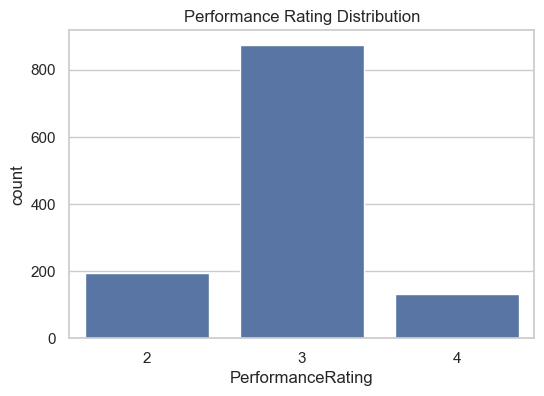

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='PerformanceRating', data=data)
plt.title("Performance Rating Distribution")
plt.show()


### Distribution of Numerical Features

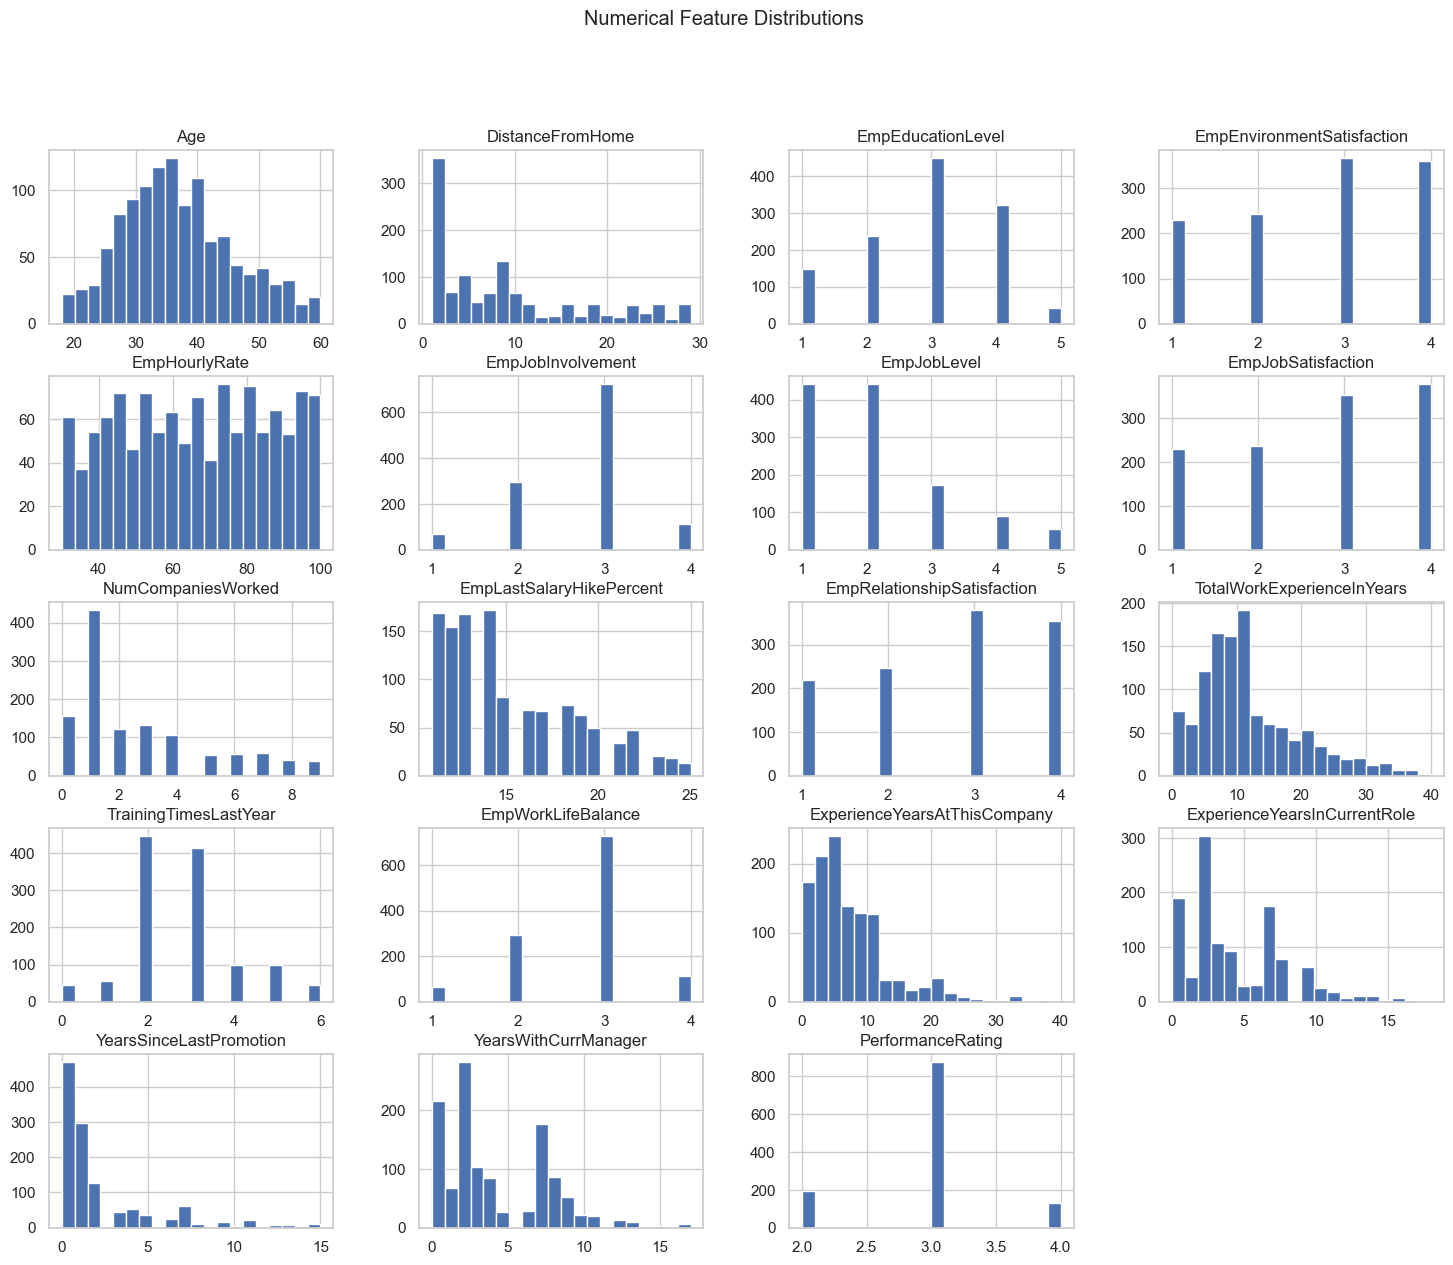

In [16]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

data[num_cols].hist(figsize=(18,14), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()


#### **Employee Data Distribution**

| Feature                      | Distribution Pattern | Key Observation             | Business Insight                            |
| ---------------------------- | -------------------- | --------------------------- | ------------------------------------------- |
| Age                          | Mostly 30–45 years   | Mid-career workforce        | Stable and experienced employees            |
| DistanceFromHome             | Mostly 1–10 km       | Right-skewed                | Employees live near workplace               |
| EmpEducationLevel            | Levels 2–4 dominant  | Moderate education          | Skilled workforce                           |
| EmpEnvironmentSatisfaction   | Mostly 3–4           | High satisfaction           | Positive work environment                   |
| EmpHourlyRate                | Uniform distribution | Balanced pay                | Fair compensation structure                 |
| EmpJobInvolvement            | Mostly level 3       | Good involvement            | Employees engaged in work                   |
| EmpJobLevel                  | Mostly levels 1–2    | Few senior roles            | Entry and mid-level heavy structure         |
| EmpJobSatisfaction           | Mostly 3–4           | Positive satisfaction       | Employees generally happy                   |
| NumCompaniesWorked           | Mostly 1–3           | Stable careers              | Low job hopping                             |
| EmpLastSalaryHikePercent     | Mostly 11–18%        | Moderate hikes              | Consistent salary increments                |
| EmpRelationshipSatisfaction  | Mostly 3–4           | Good relationships          | Healthy workplace relations                 |
| TotalWorkExperienceInYears   | Mostly 5–15 years    | Experienced staff           | Skilled workforce                           |
| TrainingTimesLastYear        | Mostly 2–3           | Regular training            | Focus on skill development                  |
| EmpWorkLifeBalance           | Mostly level 3       | Moderate balance            | Improvement opportunity                     |
| ExperienceYearsAtThisCompany | Mostly 0–10 years    | Medium tenure               | Moderate retention                          |
| ExperienceYearsInCurrentRole | Mostly 2–6 years     | Role stability              | Balanced role changes                       |
| YearsSinceLastPromotion      | Mostly 0–3 years     | Some long gaps              | Uneven promotion cycles                     |
| YearsWithCurrManager         | Mostly 2–6 years     | Stable management           | Strong manager relationships                |
| PerformanceRating            | Mostly rating 3      | Average performers dominate | Need strategies to increase high performers |

**Conclusion :**

- Workforce is mainly mid-career and experienced.
- Job satisfaction, environment satisfaction, and work-life balance are moderate to good.
- Most employees are average performers.
- Company structure has more entry and mid-level roles.
- Training and promotions are moderately frequent.

## OUTLIER DETECTION

### Boxplots for Numerical Features

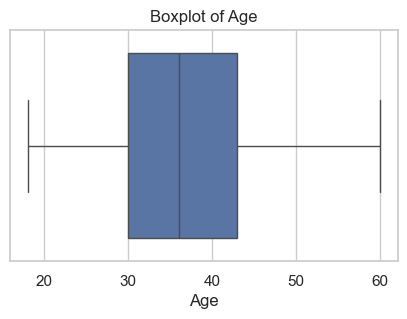

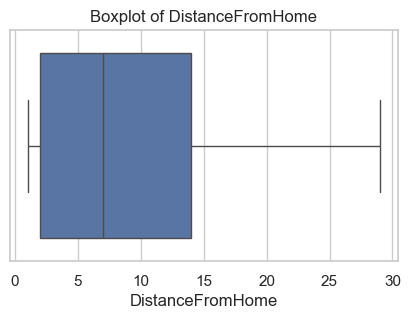

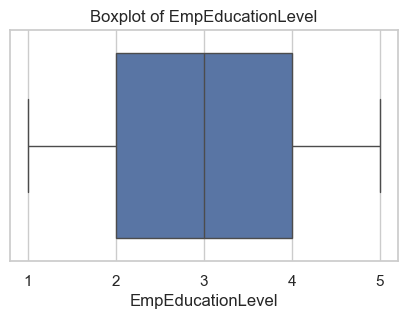

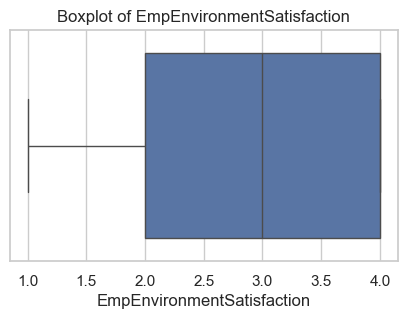

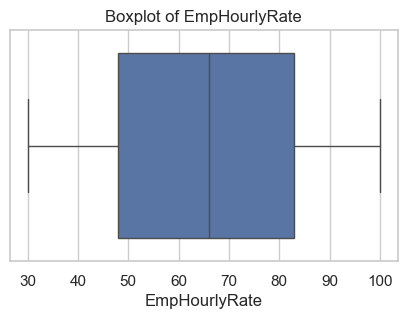

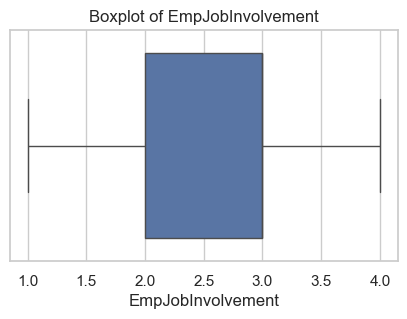

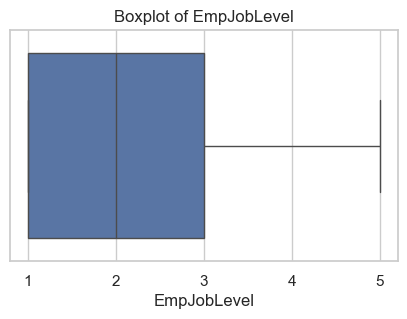

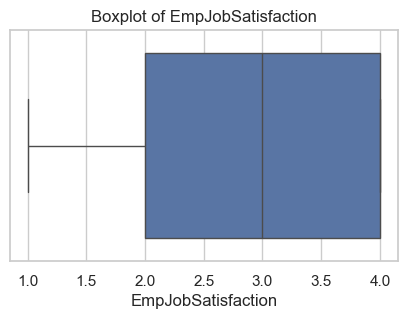

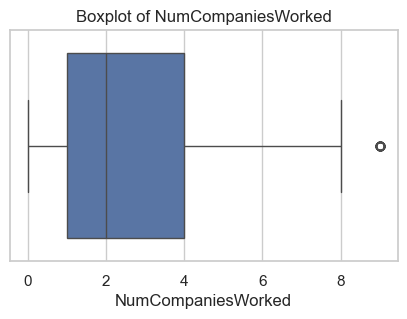

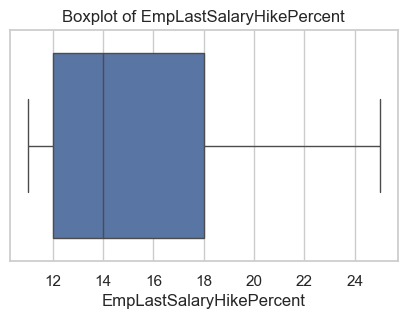

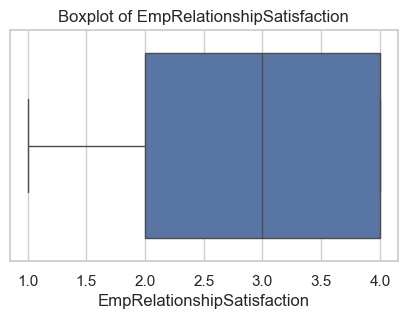

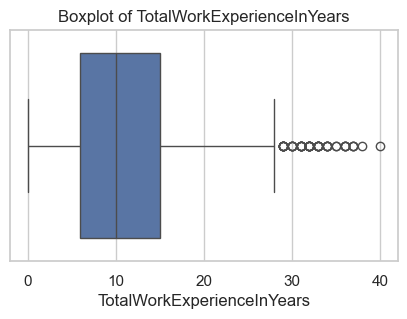

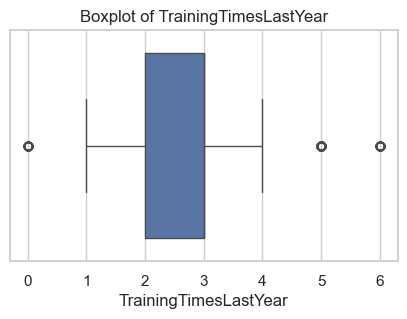

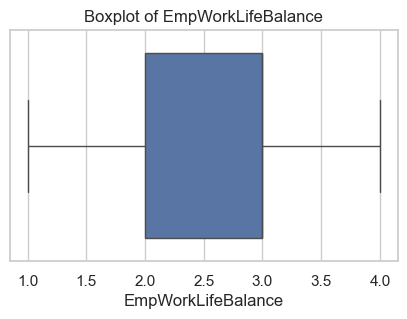

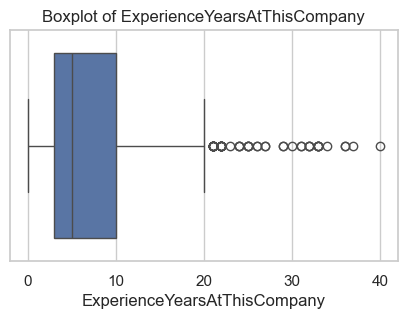

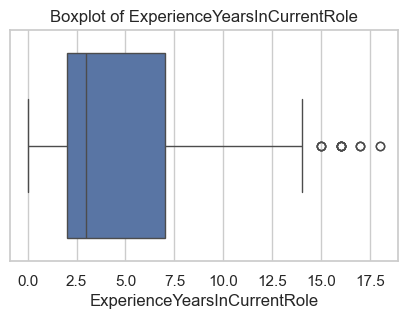

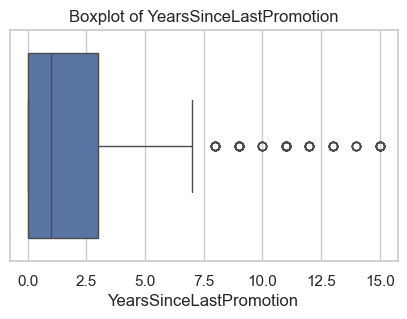

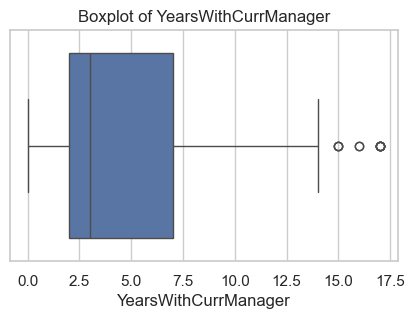

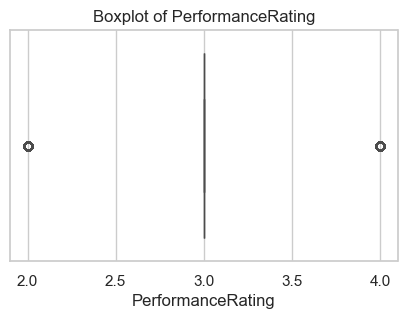

In [20]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


#### **Outlier Analysis**

| Feature                      | Outlier Presence    | Observation                                | Action Taken                 |
| ---------------------------- | ------------------- | ------------------------------------------ | ---------------------------- |
| TotalWorkExperienceInYears   | Yes (high values)   | Few employees with 30–40 years experience  | Kept (realistic values)      |
| TrainingTimesLastYear        | Minor outliers      | Some employees with 5–6 trainings          | Kept (valid training counts) |
| ExperienceYearsAtThisCompany | Yes (high tenure)   | Long-tenure employees present              | Kept (valid HR data)         |
| ExperienceYearsInCurrentRole | Few high values     | Some long role durations                   | Kept                         |
| YearsSinceLastPromotion      | Several high values | Some employees not promoted for many years | Kept (business reality)      |
| YearsWithCurrManager         | Few high values     | Long manager relationships                 | Kept                         |
| PerformanceRating            | No major outliers   | Values within expected range               | No action needed             |

- Outliers detected in experience-related features.
- These values represent real employee tenure.
- No data errors found.
- No outlier removal performed.

### Categorical Features vs Performance

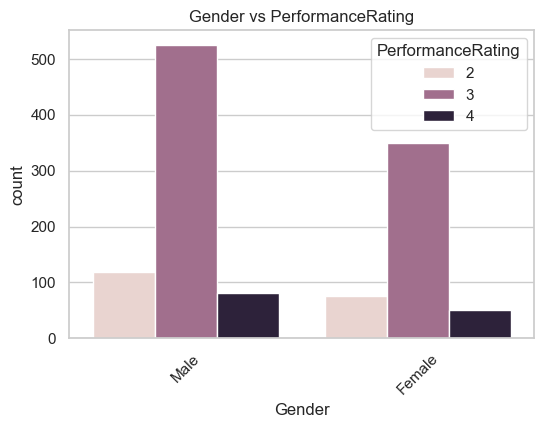

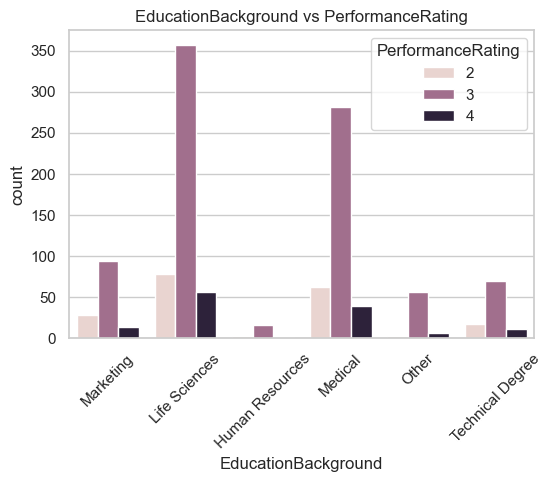

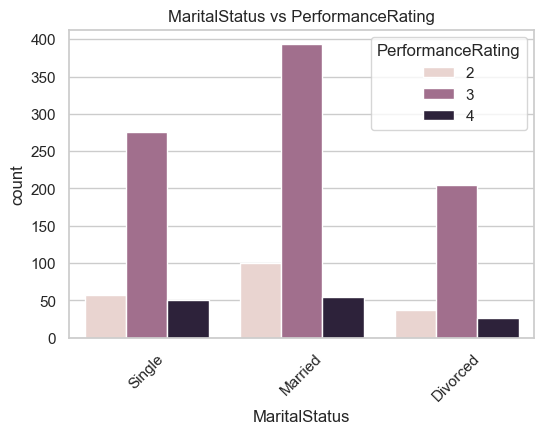

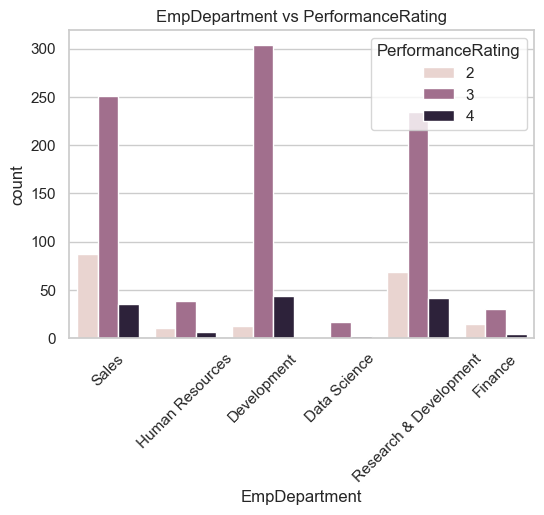

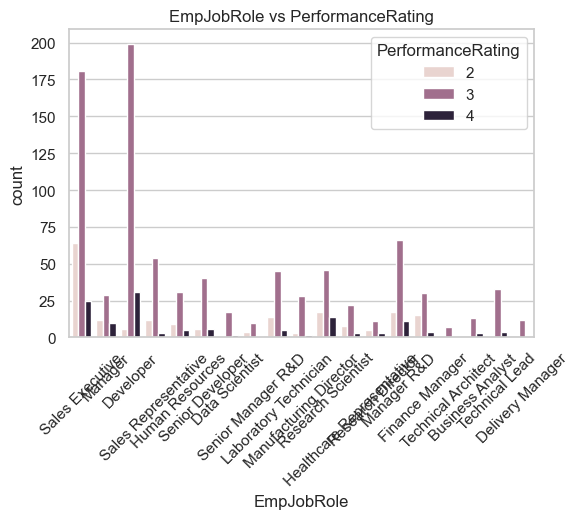

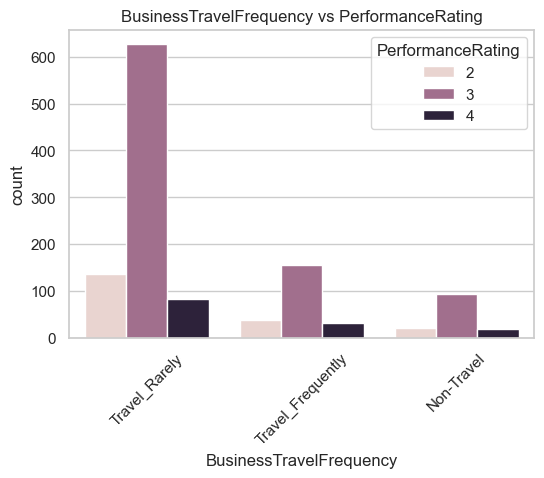

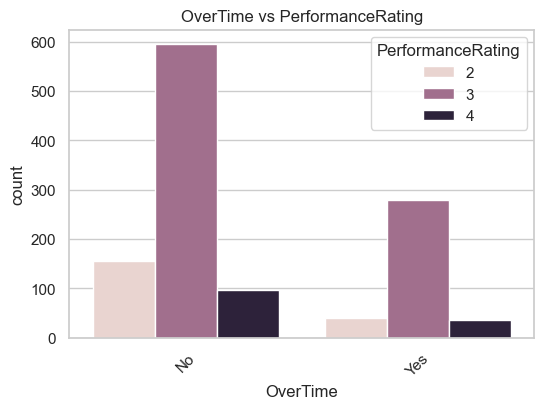

In [22]:
cat_cols = data.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='PerformanceRating', data=data)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs PerformanceRating")
    plt.show()


#### **Categorical Features vs Performance**

| Feature                 | Key Pattern Observed                        | Performance Trend                    | Business Insight                                  |
| ----------------------- | ------------------------------------------- | ------------------------------------ | ------------------------------------------------- |
| Gender                  | Similar distribution across male and female | No major difference                  | Gender does not significantly affect performance  |
| Education Background    | Life Sciences and Medical dominate          | Most employees in rating 3           | Education field has limited impact on performance |
| Marital Status          | Married employees are highest in count      | Majority have rating 3               | Marital status has minimal effect on performance  |
| EmpDepartment           | Development and Sales have most employees   | Majority rating 3 across departments | Performance is consistent across departments      |
| EmpJobRole              | Some roles have more employees              | Most roles centered at rating 3      | Job role has moderate impact on performance       |
| BusinessTravelFrequency | Travel rarely group is highest              | Mostly rating 3                      | Travel frequency has limited performance impact   |
| OverTime                | More employees without overtime             | Both groups mostly rating 3          | Overtime does not strongly affect performance     |


## MULTIVARIATE ANALYSIS

### Correlation Heatmap

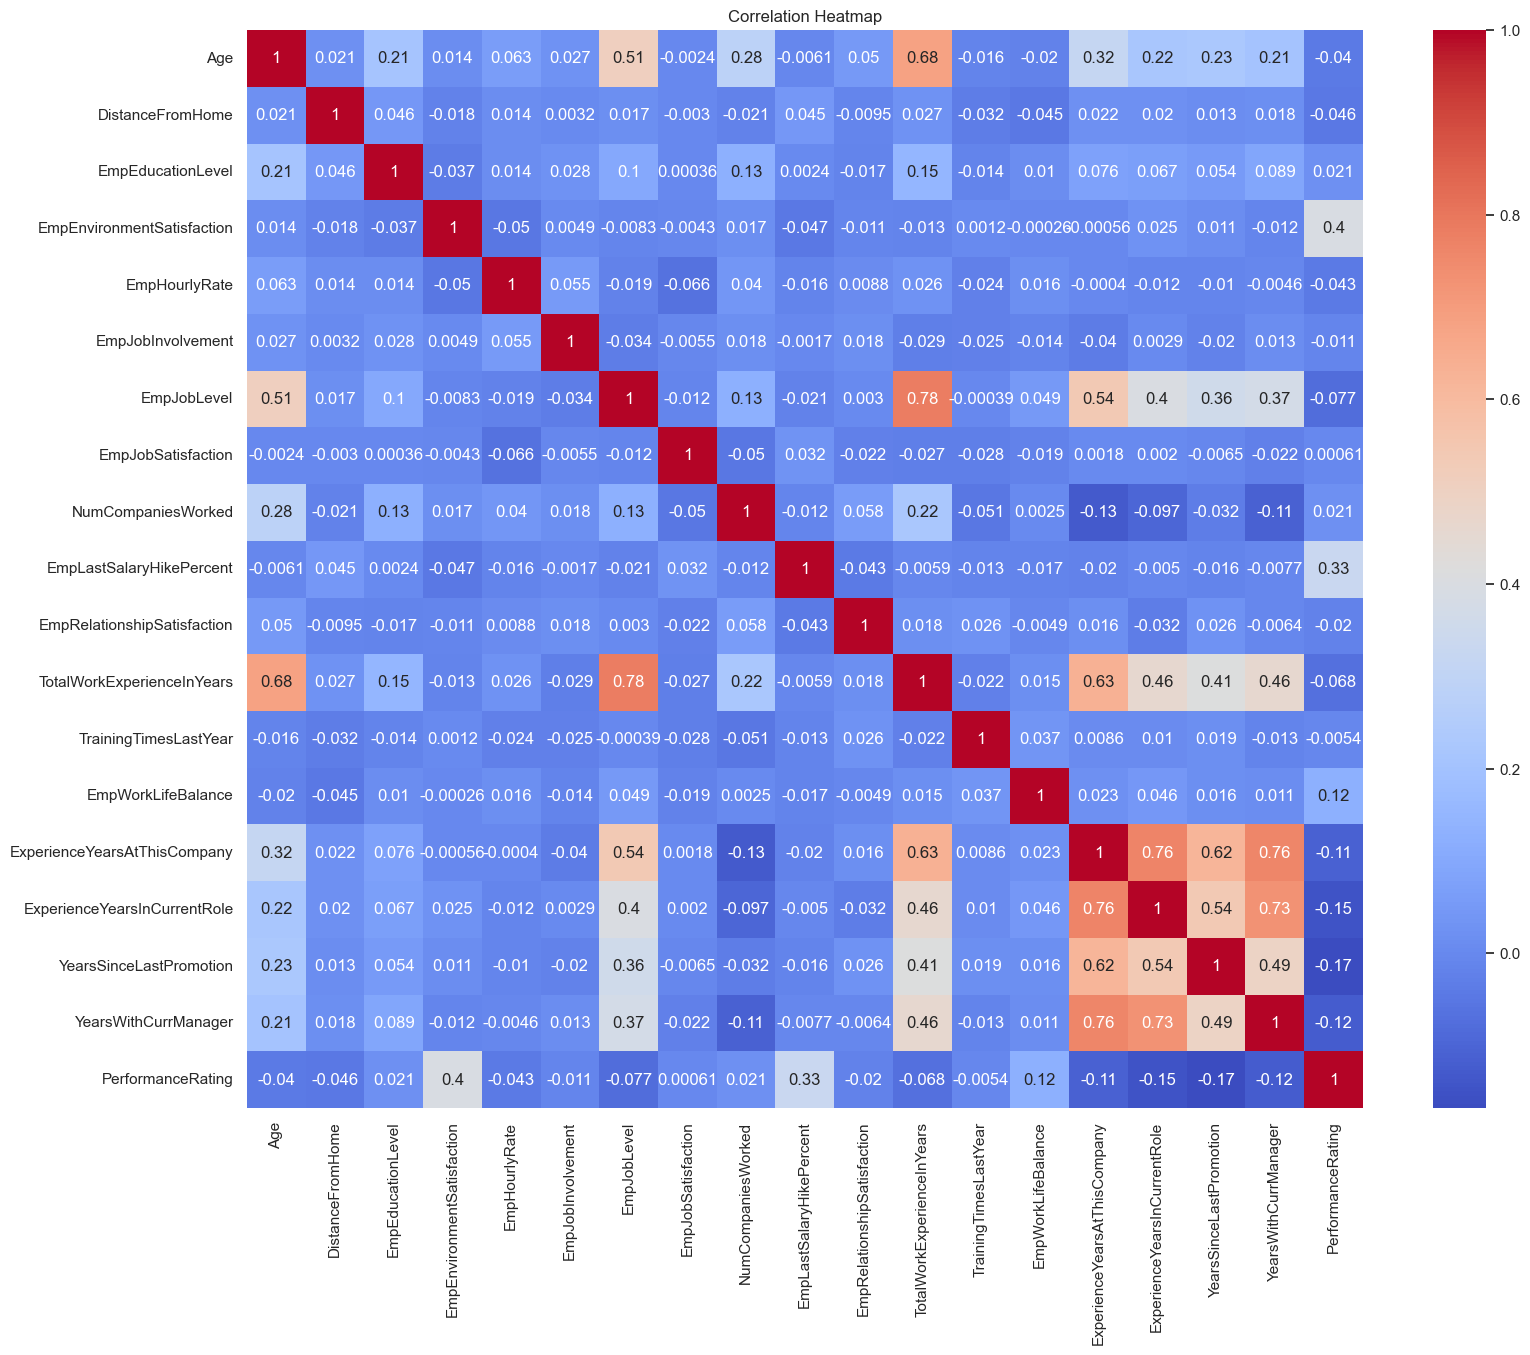

In [31]:
plt.figure(figsize=(18,14))
sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm',annot=True)
plt.title("Correlation Heatmap")
plt.show()


### Top Factors Affecting Performance

#### **From correlation with PerformanceRating**


| Feature                    | Correlation with PerformanceRating | Impact                   |
| -------------------------- | ---------------------------------- | ------------------------ |
| EmpEnvironmentSatisfaction | **0.40**                           | Strong positive impact   |
| EmpLastSalaryHikePercent   | **0.33**                           | Moderate positive impact |
| EmpWorkLifeBalance         | **0.12**                           | Slight positive impact   |

#### **Negative correlations (less impact)**

| Feature                      | Correlation |
| ---------------------------- | ----------- |
| YearsSinceLastPromotion      | -0.17       |
| ExperienceYearsInCurrentRole | -0.15       |
| YearsWithCurrManager         | -0.12       |



### Top Factors Affecting Employee Performance

| Rank | Feature                    | Correlation Value | Insight                         | Business Meaning                               |
| ---- | -------------------------- | ----------------- | ------------------------------- | ---------------------------------------------- |
| 1    | EmpEnvironmentSatisfaction | 0.40              | Strongest positive relationship | Better environment leads to higher performance |
| 2    | EmpLastSalaryHikePercent   | 0.33              | Moderate positive impact        | Higher salary hikes motivate employees         |
| 3    | EmpWorkLifeBalance         | 0.12              | Slight positive impact          | Balanced life improves performance             |


### Key Multivariate Insights

| Area                 | Observation                                     |
| -------------------- | ----------------------------------------------- |
| Strongest driver     | Environment satisfaction                        |
| Financial motivation | Salary hike affects performance                 |
| Behavioral factor    | Work-life balance influences results            |
| Negative influence   | Long time without promotion reduces performance |


### Pairplot

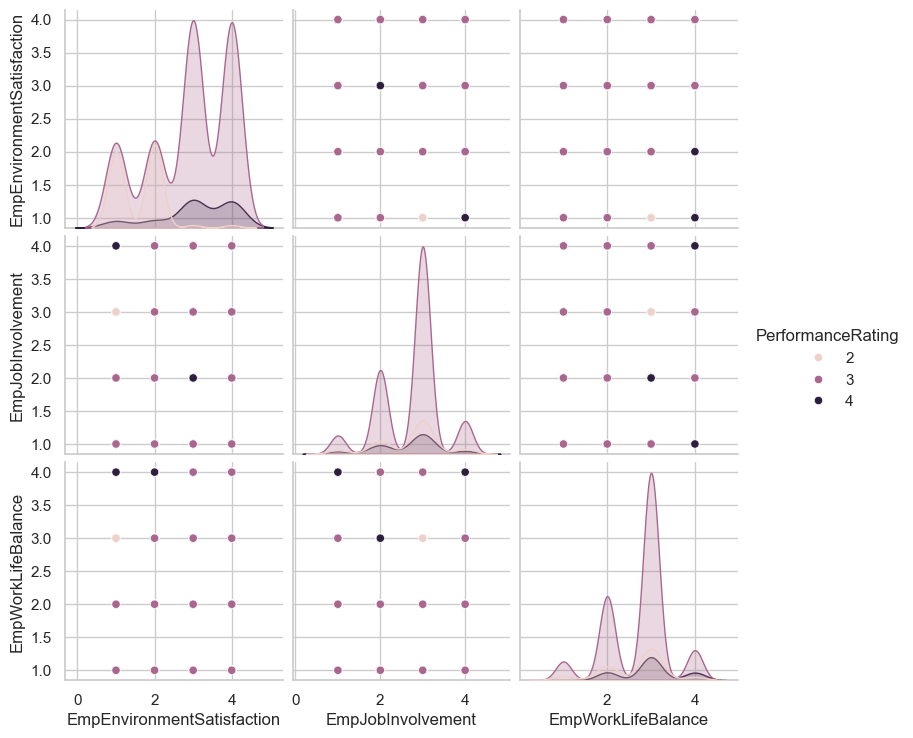

In [32]:
key_features = [
    'EmpEnvironmentSatisfaction',
    'EmpJobInvolvement',
    'EmpWorkLifeBalance',
    'PerformanceRating'
]

sns.pairplot(data[key_features], hue='PerformanceRating')
plt.show()


#### **Key Satisfaction Factors vs Performance**

| Feature Combination                     | Observed Pattern                                              | Performance Trend            | Business Insight                                        |
| --------------------------------------- | ------------------------------------------------------------- | ---------------------------- | ------------------------------------------------------- |
| Environment Satisfaction vs Performance | Higher satisfaction levels show more rating 3 and 4 employees | Positive relationship        | Better work environment improves performance            |
| Job Involvement vs Performance          | Higher involvement levels cluster around higher ratings       | Moderate positive impact     | Engaged employees perform better                        |
| Work-Life Balance vs Performance        | Higher balance levels show more rating 3 and 4                | Slight positive relationship | Balanced employees perform more consistently            |
| Environment + Job Involvement           | High values in both show better performance clusters          | Strong combined effect       | Satisfaction and involvement together boost performance |
| Job Involvement + Work-Life Balance     | Higher values lead to better performance distribution         | Moderate combined impact     | Engagement and balance together improve outcomes        |
| Environment + Work-Life Balance         | Higher satisfaction and balance lead to higher ratings        | Positive combined influence  | Healthy work culture improves results                   |

- Employee performance is mainly influenced by work environment satisfaction.
- Salary hikes act as a strong motivational factor.
- Work-life balance also contributes to better performance.
- Long gaps in promotion may reduce employee performance.

### FEATURE IMPORTANCE

### Correlation with Target

In [36]:
corr = data.corr(numeric_only=True)['PerformanceRating'].sort_values(ascending=False)
print(corr)

PerformanceRating               1.000000
EmpEnvironmentSatisfaction      0.395561
EmpLastSalaryHikePercent        0.333722
EmpWorkLifeBalance              0.124429
NumCompaniesWorked              0.020980
EmpEducationLevel               0.020529
EmpJobSatisfaction              0.000606
TrainingTimesLastYear          -0.005443
EmpJobInvolvement              -0.010539
EmpRelationshipSatisfaction    -0.019502
Age                            -0.040164
EmpHourlyRate                  -0.043116
DistanceFromHome               -0.046142
TotalWorkExperienceInYears     -0.068141
EmpJobLevel                    -0.076632
ExperienceYearsAtThisCompany   -0.111645
YearsWithCurrManager           -0.122313
ExperienceYearsInCurrentRole   -0.147638
YearsSinceLastPromotion        -0.167629
Name: PerformanceRating, dtype: float64


### Top 10 Features Affecting Performance

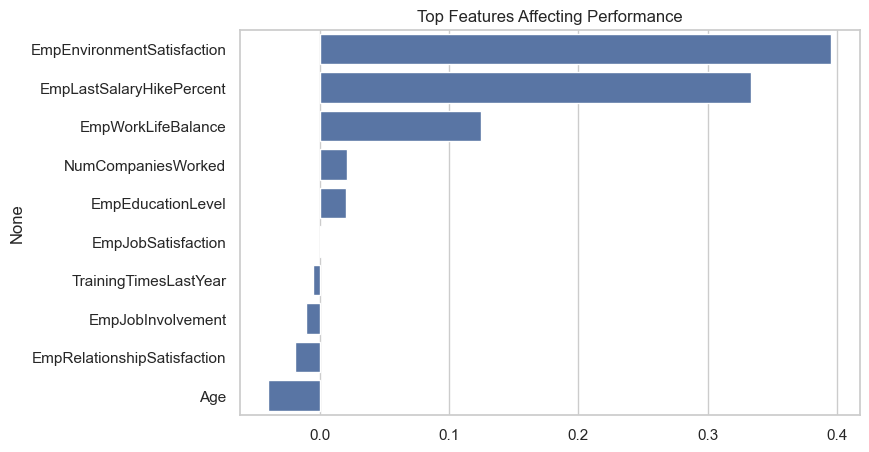

In [37]:
top_features = corr[1:11]

plt.figure(figsize=(8,5))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top Features Affecting Performance")
plt.show()


#### **Top Features Affecting Employee Performance**

| Rank | Feature                    | Impact Level       | Insight                                        |
| ---- | -------------------------- | ------------------ | ---------------------------------------------- |
| 1    | EmpEnvironmentSatisfaction | Strong             | Better environment leads to higher performance |
| 2    | EmpLastSalaryHikePercent   | Moderate           | Higher salary hikes improve motivation         |
| 3    | EmpWorkLifeBalance         | Slight to Moderate | Balanced employees perform more consistently   |
| 4    | NumCompaniesWorked         | Slight             | Experience across companies has minor impact   |
| 5    | EmpEducationLevel          | Slight             | Education level has limited effect             |

- Environment satisfaction is the strongest factor affecting performance.
- Salary hikes play an important motivational role.
- Work-life balance contributes to stable performance.
- Other factors have minimal influence compared to these top three.

## DEPARTMENT-WISE PERFORMANCE

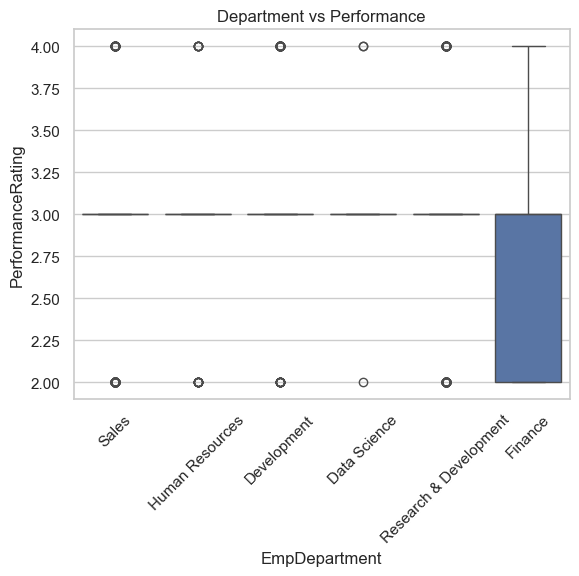

In [39]:
sns.boxplot(x='EmpDepartment', y='PerformanceRating', data=data)
plt.xticks(rotation=45)
plt.title("Department vs Performance")
plt.show()


### Department-wise Performance Summary

| Department             | Performance Pattern | Key Observation             | Business Insight              |
| ---------------------- | ------------------- | --------------------------- | ----------------------------- |
| Sales                  | Mostly rating 3     | Few low and high performers | Performance is stable         |
| Human Resources        | Mostly rating 3     | Limited variation           | Consistent performance        |
| Development            | Mostly rating 3     | Some high performers        | Strong technical output       |
| Data Science           | Mostly rating 3     | Few high performers         | Stable analytical performance |
| Research & Development | Mostly rating 3     | Balanced distribution       | Consistent productivity       |
| Finance                | Wider spread (2–4)  | More variation in ratings   | Mixed performance levels      |


## OVERTIME VS PERFORMANCE

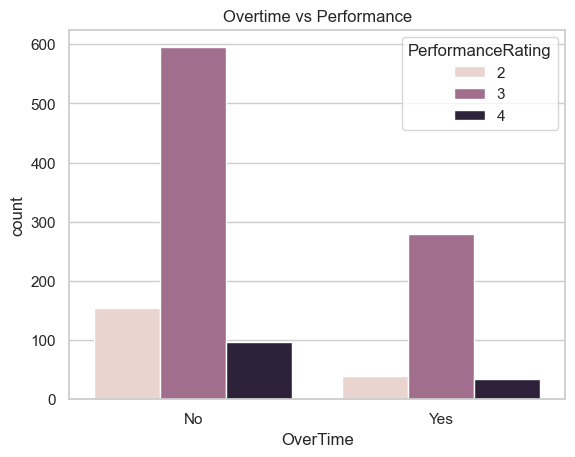

In [40]:
sns.countplot(x='OverTime', hue='PerformanceRating', data=data)
plt.title("Overtime vs Performance")
plt.show()

### **Overtime vs Performance**

| Overtime Status | Performance Pattern                    | Key Observation                                        | Business Insight                              |
| --------------- | -------------------------------------- | ------------------------------------------------------ | --------------------------------------------- |
| No Overtime     | Majority rating 3, some rating 2 and 4 | Most employees without overtime are average performers | Normal work hours maintain stable performance |
| Overtime (Yes)  | Majority rating 3, fewer rating 4      | Fewer high performers compared to no overtime group    | Excess overtime may not improve performance   |


| Observation                                        | Conclusion                                                |
| -------------------------------------------------- | --------------------------------------------------------- |
| Most employees fall under rating 3 in both groups  | Overtime does not significantly change performance levels |
| High performers slightly more in no-overtime group | Balanced work hours may support better performance        |



## Encode Categorical Variables

In [45]:
le = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

## Split Features and Target

In [47]:
X = data.drop("PerformanceRating", axis=1)
y = data["PerformanceRating"]


## Train-Test Split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Model

# Random Forest

In [53]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Model Evaluation

In [54]:
y_pred = model.predict(X_test)
y_pred

array([3, 2, 3, 3, 3, 3, 3, 3, 2, 3, 3, 4, 3, 3, 2, 2, 3, 3, 4, 2, 2, 3,
       3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 2, 3, 4, 3,
       3, 3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3,
       3, 4, 3, 2, 2, 3, 4, 4, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3,
       3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 3, 3, 3, 2,
       3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3,
       3, 3, 3, 3, 4, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2,
       3, 3, 3, 4, 3, 4, 3, 3, 3, 3, 3, 4, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3,
       2, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 2, 3, 3, 3,
       4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 4, 4, 3, 3, 3, 2, 3, 3, 3, 3, 4, 3, 3, 2, 3, 3])

In [56]:
print("Accuracy:", accuracy_score(y_test, y_pred)*100)
print(classification_report(y_test, y_pred))

Accuracy: 94.58333333333333
              precision    recall  f1-score   support

           2       0.96      0.86      0.91        29
           3       0.94      0.99      0.97       184
           4       0.95      0.74      0.83        27

    accuracy                           0.95       240
   macro avg       0.95      0.86      0.90       240
weighted avg       0.95      0.95      0.94       240



### Random Forest Model Performance

| Model                      | Accuracy   | Class | Precision | Recall | F1-Score | Support | Key Insight                               |
| -------------------------- | ---------- | ----- | --------- | ------ | -------- | ------- | ----------------------------------------- |
| Random Forest              | **94.58%** | 2     | 0.96      | 0.86   | 0.91     | 29      | Good prediction for low performers        |
| Random Forest              | **94.58%** | 3     | 0.94      | 0.99   | 0.97     | 184     | Majority class predicted very accurately  |
| Random Forest              | **94.58%** | 4     | 0.95      | 0.74   | 0.83     | 27      | High performers slightly harder to detect |
| **Overall (Macro Avg)**    | **94.58%** | All   | 0.95      | 0.86   | 0.90     | 240     | Balanced performance across classes       |
| **Overall (Weighted Avg)** | **94.58%** | All   | 0.95      | 0.95   | 0.94     | 240     | Strong overall model performance          |


## Feature Importance

In [59]:
importance = model.feature_importances_
features = X.columns

imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(imp_df.head(10))

                         Feature  Importance
9     EmpEnvironmentSatisfaction    0.215138
16      EmpLastSalaryHikePercent    0.212594
23       YearsSinceLastPromotion    0.096485
5                     EmpJobRole    0.047864
22  ExperienceYearsInCurrentRole    0.039379
4                  EmpDepartment    0.038511
10                 EmpHourlyRate    0.036764
21  ExperienceYearsAtThisCompany    0.031723
0                            Age    0.030073
20            EmpWorkLifeBalance    0.026409


## Feature Importance

| Rank | Feature                      | Importance Score | Impact Level | Business Insight                             |
| ---- | ---------------------------- | ---------------- | ------------ | -------------------------------------------- |
| 1    | EmpLastSalaryHikePercent     | 0.2126           | Strong       | Salary hikes strongly influence performance  |
| 2    | EmpEnvironmentSatisfaction   | 0.2151           | Strong       | Better work environment improves performance |
| 3    | YearsSinceLastPromotion      | 0.0965           | Moderate     | Long promotion gaps reduce performance       |
| 4    | EmpJobRole                   | 0.0479           | Moderate     | Job role affects performance levels          |
| 5    | ExperienceYearsInCurrentRole | 0.0394           | Moderate     | Role experience impacts performance          |
| 6    | EmpDepartment                | 0.0385           | Slight       | Department has minor influence               |
| 7    | EmpHourlyRate                | 0.0368           | Slight       | Pay rate slightly affects performance        |
| 8    | ExperienceYearsAtThisCompany | 0.0317           | Slight       | Company tenure has small impact              |
| 9    | Age                          | 0.0301           | Slight       | Age has minimal effect on performance        |
| 10   | EmpWorkLifeBalance           | 0.0264           | Slight       | Work-life balance has minor influence        |


## Support Vector Machine

## Define parameter grid

## Apply StandardScaler

In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [95]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}


## Apply Grid Search

In [103]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm = SVC()

grid = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Use scaled data here
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

## Train final SVM model

In [104]:
best_svm = grid.best_estimator_

y_pred = best_svm.predict(X_test_scaled)
y_pred

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 4, 3, 3, 3, 3, 3, 3, 4, 2, 2, 3,
       3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 3, 3, 3, 2, 3, 4, 3,
       3, 3, 3, 2, 2, 3, 2, 2, 3, 3, 2, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3,
       2, 4, 3, 3, 2, 3, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3,
       3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 4, 3, 3, 3, 3, 2,
       3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2,
       3, 3, 3, 3, 4, 3, 3, 2, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2,
       3, 2, 3, 4, 2, 3, 3, 3, 3, 3, 3, 4, 4, 3, 3, 4, 3, 3, 3, 3, 3, 3,
       2, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3,
       3, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 4, 4, 3, 3, 3, 2, 3, 3, 3, 4, 4, 3, 3, 3, 3, 3])

In [107]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred)*100)
print(classification_report(y_test, y_pred, zero_division=0))

SVM Accuracy: 84.16666666666667
              precision    recall  f1-score   support

           2       0.54      0.52      0.53        29
           3       0.88      0.92      0.90       184
           4       0.90      0.67      0.77        27

    accuracy                           0.84       240
   macro avg       0.77      0.70      0.73       240
weighted avg       0.84      0.84      0.84       240



## SVM Model Performance

| Model                      | Accuracy   | Class | Precision | Recall | F1-Score | Support | Key Insight                           |
| -------------------------- | ---------- | ----- | --------- | ------ | -------- | ------- | ------------------------------------- |
| SVM                        | **84.17%** | 2     | 0.54      | 0.52   | 0.53     | 29      | Moderate prediction of low performers |
| SVM                        | **84.17%** | 3     | 0.88      | 0.92   | 0.90     | 184     | Majority class predicted very well    |
| SVM                        | **84.17%** | 4     | 0.90      | 0.67   | 0.77     | 27      | High performers predicted reasonably  |
| **Overall (Macro Avg)**    | **84.17%** | All   | 0.77      | 0.70   | 0.73     | 240     | Balanced but lower than Random Forest |
| **Overall (Weighted Avg)** | **84.17%** | All   | 0.84      | 0.84   | 0.84     | 240     | Good overall performance              |


## Train Final Model

In [109]:
final_svm = best_svm
final_svm.fit(X_train_scaled, y_train)


SVC(C=0.1, kernel='linear')

## feature importance

In [110]:
if final_svm.kernel == 'linear':
    importance = final_svm.coef_[0]
    features = X.columns

    import pandas as pd
    imp_df = pd.DataFrame({
        "Feature": features,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)

    print(imp_df.head(10))

                         Feature  Importance
4                  EmpDepartment    0.682639
22  ExperienceYearsInCurrentRole    0.417725
23       YearsSinceLastPromotion    0.354797
7               DistanceFromHome    0.170093
17   EmpRelationshipSatisfaction    0.156973
14            NumCompaniesWorked    0.117652
24          YearsWithCurrManager    0.100094
10                 EmpHourlyRate    0.093045
12                   EmpJobLevel    0.086430
13            EmpJobSatisfaction    0.075658


## feature importance

| Rank | Feature                      | Importance Score | Impact Level | Business Insight                             |
| ---- | ---------------------------- | ---------------- | ------------ | -------------------------------------------- |
| 1    | EmpDepartment                | 0.6826           | Strong       | Department plays major role in performance   |
| 2    | ExperienceYearsInCurrentRole | 0.4177           | Strong       | Role experience improves performance         |
| 3    | YearsSinceLastPromotion      | 0.3548           | Moderate     | Long promotion gaps reduce performance       |
| 4    | DistanceFromHome             | 0.1701           | Moderate     | Longer travel may affect performance         |
| 5    | EmpRelationshipSatisfaction  | 0.1570           | Moderate     | Better relationships improve performance     |
| 6    | NumCompaniesWorked           | 0.1177           | Slight       | Previous company experience has some impact  |
| 7    | YearsWithCurrManager         | 0.1001           | Slight       | Manager relationship duration affects output |
| 8    | EmpHourlyRate                | 0.0930           | Slight       | Pay level has small influence                |
| 9    | EmpJobLevel                  | 0.0864           | Slight       | Job hierarchy slightly affects performance   |
| 10   | EmpJobSatisfaction           | 0.0757           | Slight       | Satisfaction contributes modestly            |


## Neural Network

## Apply StandardScaler

In [111]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Hyperparameter tuning

In [113]:
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100,50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001],
    'learning_rate': ['constant', 'adaptive']
}

mlp = MLPClassifier(max_iter=500, random_state=42)

grid = GridSearchCV(
    mlp,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'solver': 'adam'}


## Train final Neural Network model

In [115]:
best_nn = grid.best_estimator_

y_pred = best_nn.predict(X_test_scaled)
y_pred

array([3, 3, 3, 3, 3, 3, 2, 3, 2, 4, 3, 4, 3, 2, 3, 3, 3, 3, 4, 2, 2, 3,
       3, 3, 3, 4, 3, 3, 3, 3, 3, 4, 3, 3, 2, 3, 2, 3, 3, 3, 2, 4, 4, 3,
       3, 3, 3, 2, 2, 2, 2, 2, 3, 3, 2, 3, 3, 3, 3, 2, 2, 3, 3, 3, 3, 2,
       3, 4, 3, 3, 2, 3, 3, 4, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 4, 3, 3, 3,
       3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 4,
       3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 4, 3, 2, 2, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 4, 3, 3, 3, 3, 2, 3, 3, 4, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3,
       2, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 2, 3, 3, 3,
       3, 4, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3,
       3, 3, 3, 3, 4, 4, 3, 3, 3, 2, 3, 3, 3, 4, 4, 3, 3, 3, 3, 3])

## Model evaluation

In [117]:
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred)*100)
print(classification_report(y_test, y_pred, zero_division=0))

Neural Network Accuracy: 81.66666666666667
              precision    recall  f1-score   support

           2       0.50      0.52      0.51        29
           3       0.88      0.89      0.88       184
           4       0.72      0.67      0.69        27

    accuracy                           0.82       240
   macro avg       0.70      0.69      0.69       240
weighted avg       0.82      0.82      0.82       240



## Neural Netword Model Performance

| Model                      | Accuracy   | Class | Precision | Recall | F1-Score | Support | Key Insight                           |
| -------------------------- | ---------- | ----- | --------- | ------ | -------- | ------- | ------------------------------------- |
| Neural Network             | **81.67%** | 2     | 0.50      | 0.52   | 0.51     | 29      | Moderate prediction of low performers |
| Neural Network             | **81.67%** | 3     | 0.88      | 0.89   | 0.88     | 184     | Majority class predicted very well    |
| Neural Network             | **81.67%** | 4     | 0.72      | 0.67   | 0.69     | 27      | High performers predicted reasonably  |
| **Overall (Macro Avg)**    | **81.67%** | All   | 0.70      | 0.69   | 0.69     | 240     | Balanced but lower performance        |
| **Overall (Weighted Avg)** | **81.67%** | All   | 0.82      | 0.82   | 0.82     | 240     | Good overall accuracy                 |


## Final model training

In [121]:
final_nn = best_nn
final_nn.fit(X_train_scaled, y_train)


MLPClassifier(max_iter=500, random_state=42)

## Feature importance

In [122]:
result = permutation_importance(
    final_nn, X_test_scaled, y_test,
    n_repeats=10,
    random_state=42
)

importance = result.importances_mean
features = X.columns

imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(imp_df.head(10))

                         Feature  Importance
16      EmpLastSalaryHikePercent    0.115000
9     EmpEnvironmentSatisfaction    0.094583
23       YearsSinceLastPromotion    0.035833
22  ExperienceYearsInCurrentRole    0.014583
3                  MaritalStatus    0.012500
21  ExperienceYearsAtThisCompany    0.011250
4                  EmpDepartment    0.007083
5                     EmpJobRole    0.004583
19         TrainingTimesLastYear    0.003333
18    TotalWorkExperienceInYears    0.002500


## Feature Importance

| Rank | Feature                      | Importance Score | Impact Level | Business Insight                             |
| ---- | ---------------------------- | ---------------- | ------------ | -------------------------------------------- |
| 1    | EmpLastSalaryHikePercent     | 0.1150           | Strong       | Salary hikes strongly influence performance  |
| 2    | EmpEnvironmentSatisfaction   | 0.0946           | Strong       | Better work environment improves performance |
| 3    | YearsSinceLastPromotion      | 0.0358           | Moderate     | Long promotion gaps may reduce performance   |
| 4    | ExperienceYearsInCurrentRole | 0.0146           | Moderate     | Role experience improves performance         |
| 5    | MaritalStatus                | 0.0125           | Slight       | Personal factors have small influence        |
| 6    | ExperienceYearsAtThisCompany | 0.0113           | Slight       | Company tenure has minor impact              |
| 7    | EmpDepartment                | 0.0071           | Slight       | Department affects performance slightly      |
| 8    | EmpJobRole                   | 0.0046           | Slight       | Job role has limited impact                  |
| 9    | TrainingTimesLastYear        | 0.0033           | Slight       | Training has small influence                 |
| 10   | TotalWorkExperienceInYears   | 0.0025           | Slight       | Overall experience has minimal impact        |


## Final Model Table


| Model              | Overall Accuracy | Class 2 F1 | Class 3 F1 | Class 4 F1 | Weighted F1 | Key Strength                              | Key Limitation                    | Final Verdict    |
| ------------------ | ---------------- | ---------- | ---------- | ---------- | ----------- | ----------------------------------------- | --------------------------------- | ---------------- |
| **Random Forest**  | **94.58%**       | 0.91       | 0.97       | 0.83       | **0.94**    | Highest accuracy and balanced predictions | Slightly lower recall for class 4 | **Best Model** |
| **SVM**            | 84.17%           | 0.53       | 0.90       | 0.77       | 0.84        | Good performance on majority class        | Lower performance on class 2      | Second best      |
| **Neural Network** | 81.67%           | 0.51       | 0.88       | 0.69       | 0.82        | Balanced overall predictions              | Lowest accuracy among models      | Third place      |


## Final Conclusion

- Random Forest achieved the highest accuracy (94.58%).

- It provided the best balance across all performance classes.

- SVM and Neural Network showed lower accuracy and weaker performance on minority classes.

- Therefore, Random Forest was selected as the final model for employee performance prediction.